In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

Data shape: (500, 141)
Data: [[[ 1.0000000e+00]
  [-1.1252183e-01]
  [-2.8272038e+00]
  ...
  [ 1.2343082e-01]
  [ 9.2528624e-01]
  [ 1.9313742e-01]]

 [[ 1.0000000e+00]
  [-1.1008778e+00]
  [-3.9968398e+00]
  ...
  [ 7.7381971e-01]
  [ 1.1196209e+00]
  [-1.4362499e+00]]

 [[ 1.0000000e+00]
  [-5.6708802e-01]
  [-2.5934502e+00]
  ...
  [ 3.2109663e-01]
  [ 9.0422673e-01]
  [-4.2179659e-01]]

 ...

 [[ 4.0000000e+00]
  [-2.1963843e-02]
  [-9.1243389e-01]
  ...
  [ 1.4442803e+00]
  [ 1.4323469e+00]
  [ 1.4570283e+00]]

 [[ 5.0000000e+00]
  [ 2.8801100e-01]
  [-1.0980196e+00]
  ...
  [ 4.9872417e-02]
  [ 1.0914960e-02]
  [-8.1534236e-02]]

 [[ 5.0000000e+00]
  [-1.1336738e+00]
  [-2.7029409e+00]
  ...
  [-1.1084010e-01]
  [ 1.8580663e-03]
  [-1.2263937e-01]]]
Time serie Steps: 500


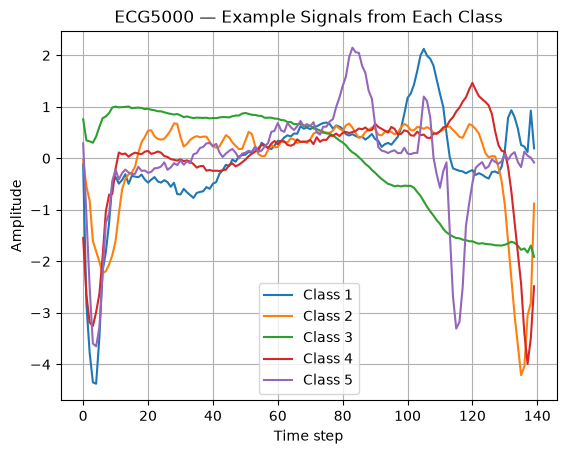

In [24]:
### Load the data

path = "../ECG5000/ECG5000_TRAIN.txt"

data = np.loadtxt(path)
print("Data shape:", data.shape)

data = np.expand_dims(data, axis=-1)

print("Data:",data)

n_time_steps = len(data)
print("Time serie Steps:", n_time_steps)

for cls in [1,2,3,4,5]:
    # find first sample of this class
    idx = np.where(data[:,0] == cls)[0][0]
    signal = data[idx, 1:]

    plt.plot(signal, label=f"Class {cls}")

plt.title("ECG5000 — Example Signals from Each Class")
plt.xlabel("Time step")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()



ValueError: x and y can be no greater than 2D, but have shapes (401, 141, 1) and (401, 141, 1)

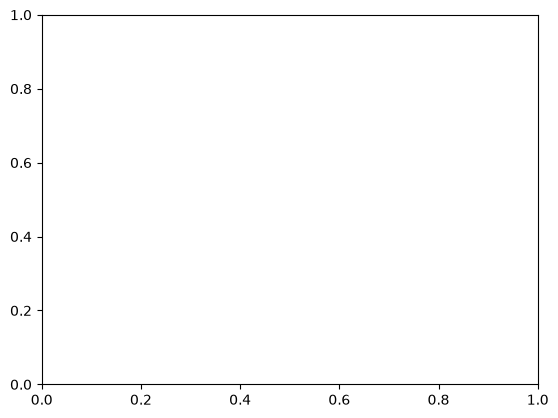

In [23]:
#Split data

train_fraction = 0.8
train_end = int(train_fraction * n_time_steps)
train_data = data[:train_end+1]
test_data = data[train_end:]


#Plot the train data
plt.plot(data[: train_end+1], train_data, label="Training data", color = "black")
plt.plot(data[train_end :], test_data, label="Test data", color = "red")
plt.legend
plt.xlabel("Time")
plt.ylabel("Signal")
plt.show()